In [1]:
### Imports ###
!pip install py7zr
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler,FunctionTransformer,OrdinalEncoder
from sklearn.pipeline import Pipeline
import os,time,py7zr,datetime,random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 6.9 MB/s eta 0:00:00


In [2]:
### Set Seed ###
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
### Extract Data ###

import os
import shutil
import pandas as pd
from zipfile import ZipFile

MAX_ROWS = 10000000

# Remove old extraction folder if it exists
if os.path.exists("readableData"):
    shutil.rmtree("readableData")

# Create extraction folder
os.makedirs("readableData", exist_ok=True)

# Download dataset from Kaggle
!kaggle datasets download -d ruiyuanfan/corporacin-favorita-grocery-sales-forecasting

# Extract ZIP contents
print("Extracting dataset...")

with ZipFile(
    "corporacin-favorita-grocery-sales-forecasting.zip",
    "r"
) as zip_ref:
    zip_ref.extractall("readableData")

print("Extraction complete.")

# Verify files
print("\nFiles found:")
print(os.listdir("readableData"))

# Load training data
print("\nLoading train.csv...")

ds = pd.read_csv(
    "readableData/train.csv",
    index_col="id",
    nrows=MAX_ROWS,
    parse_dates=["date"]
)

# Fill missing promotion values
ds["onpromotion"] = ds["onpromotion"].fillna(False)

print("\nDataset Loaded Successfully!")
print("Shape:", ds.shape)

display(ds.head())

Dataset URL: https://www.kaggle.com/datasets/ruiyuanfan/corporacin-favorita-grocery-sales-forecasting
License(s): unknown
100% 850M/850M [00:09<00:00, 94.9MB/s]

Extracting dataset...
Extraction complete.

Files found:
['train.csv', 'oil.csv', 'items.csv', 'sample_submission.csv', 'stores.csv', 'transactions.csv', 'test.csv', 'holidays_events.csv']

Loading train.csv...

Dataset Loaded Successfully!
Shape: (10000000, 5)


/tmp/ipykernel_2833/396736715.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ds["onpromotion"] = ds["onpromotion"].fillna(False)


,date,store_nbr,item_nbr,unit_sales,onpromotion
id,,,,,
0,2013-01-01,25,103665,7.0,False
1,2013-01-01,25,105574,1.0,False
2,2013-01-01,25,105575,2.0,False
3,2013-01-01,25,108079,1.0,False
4,2013-01-01,25,108701,1.0,False


In [4]:
print(ds.shape)
print()

print(ds.columns)
print()

print(ds.dtypes)

(10000000, 5)

Index(['date', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion'], dtype='object')

date           datetime64[ns]
store_nbr               int64
item_nbr                int64
unit_sales            float64
onpromotion              bool
dtype: object


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
### Data Preprocessing ###

# Target
y = ds["unit_sales"]

# IMPORTANT:
# Do NOT include unit_sales in X.
# Otherwise the model learns the answer directly.

X = ds[["date","store_nbr", "item_nbr", "onpromotion"]]

X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.4, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5,
    random_state=SEED)


dat_cols = ["date"]
num_cols = ["store_nbr", "item_nbr", "onpromotion"] # These are treated as numerical and scaled.
cat_cols = [] # Empty, as these are now treated as numerical for scaling.

##Build preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols), # Scaling store_nbr, item_nbr, onpromotion
        ("datetime",OrdinalEncoder(),dat_cols),
    ],
    remainder="drop" # Drop any other columns not explicitly transformed (none in this case)
)

X_train_p = preprocess.fit_transform(X_train)
X_val_p   = preprocess.transform(X_val)
X_test_p  = preprocess.transform(X_test)
# Verify processed feature shapes
print("Processed shapes:", X_train_p.shape, X_val_p.shape, X_test_p.shape)

Processed shapes: (6000000, 4) (2000000, 4) (2000000, 4)


In [6]:
### Build First Model ###
def build_basic_model(
    input_dim: int,
    depth: int = 5,
    width: int = 100,
    activation: str = "relu",
    kernel_initializer: str | keras.initializers.Initializer = None,
    use_batchnorm: bool = False,
    dropout_rate: float = 0,
    l2_weight: float = 0,
) -> keras.Model:

    reg = keras.regularizers.L2(l2=l2_weight) if l2_weight and l2_weight > 0 else None

    inputs = keras.Input(shape=(input_dim ,))
    x = inputs

    for _ in range(depth):
        x = layers.Dense(
            width,
            activation=None,
            kernel_initializer=kernel_initializer,
            kernel_regularizer=reg ,
        )(x)

        if use_batchnorm:
            x = layers.BatchNormalization()(x)

        x = layers.Activation(activation=activation)(x)

        if dropout_rate and dropout_rate > 0:
            x = layers.Dropout(rate=dropout_rate)(x)

    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

input_dim = X_train_p.shape[1]
deep_model = build_basic_model(input_dim=input_dim, depth=6, width=256)
deep_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,497 (1.26 MB)

 Trainable params: 330,497 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
### Compile & Fit Functions ###

def compile_model(model: keras.Model, optimizer: keras.optimizers.Optimizer):
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.MeanSquaredError(),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae"),
                  keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model

def fit_model(model: keras.Model, epochs: int = 20, batch_size: int = 256):
    history = model.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=True
    )
    return history

print(X_train_p)
print(y_train)
print(X_val_p)
print(y_val)

[[-4.07288354e-02  6.48539515e-01  0.00000000e+00  1.61000000e+02]
 [ 1.47839391e+00  3.81712901e-01  0.00000000e+00  2.29000000e+02]
 [ 1.41762900e+00  1.29746782e+00  0.00000000e+00  8.00000000e+01]
 ...
 [-1.25602703e+00 -2.38891906e-01  0.00000000e+00  1.04000000e+02]
 [ 2.02330804e-01 -7.39947832e-01  0.00000000e+00  1.55000000e+02]
 [ 8.70744813e-01 -1.66608199e+00  0.00000000e+00  1.52000000e+02]]
id
6818780     2.0
9907176    60.0
3304275    25.0
9020937     2.0
3082311    13.0
           ... 
9958614     3.0
2234489     2.0
4304572    13.0
6550634     1.0
6423388     8.0
Name: unit_sales, Length: 6000000, dtype: float64
[[-1.07373230e+00  1.62150109e+00  0.00000000e+00  1.92000000e+02]
 [ 2.63095714e-01 -1.31156407e-01  0.00000000e+00  9.40000000e+01]
 [ 8.09979903e-01 -2.40240189e-01  0.00000000e+00  1.48000000e+02]
 ...
 [-8.30672664e-01 -1.64477974e+00  0.00000000e+00  9.30000000e+01]
 [ 6.27685174e-01 -6.72886618e-01  0.00000000e+00  7.00000000e+00]
 [-6.48377934e-01  4.15

Epoch 1/20
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 110s 4ms/step - loss: 352.5645 - mae: 7.4058 - rmse: 18.7767 - val_loss: 365.8663 - val_mae: 7.4418 - val_rmse: 19.1276
Epoch 2/20
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 131s 4ms/step - loss: 350.6874 - mae: 7.3576 - rmse: 18.7266 - val_loss: 363.5553 - val_mae: 7.4226 - val_rmse: 19.0671
Epoch 3/20
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 150s 4ms/step - loss: 351.6893 - mae: 7.4019 - rmse: 18.7534 - val_loss: 365.8761 - val_mae: 7.4766 - val_rmse: 19.1279
Epoch 4/20
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 100s 4ms/step - loss: 350.8953 - mae: 7.3757 - rmse: 18.7322 - val_loss: 361.6802 - val_mae: 7.2897 - val_rmse: 19.0179
Epoch 5/20
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 93s 4ms/step - loss: 349.3765 - mae: 7.3231 - rmse: 18.6916 - val_loss: 365.7188 - val_mae: 7.4422 - val_rmse: 19.1238
Epoch 6/20
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 92s 4ms/step - loss: 349.8935 - mae: 7.3422 - rmse: 18.7054 - val_loss: 365.4560 - val_mae: 7.4953 - val_rmse: 19.1169
Epoch 7/20
23438/2

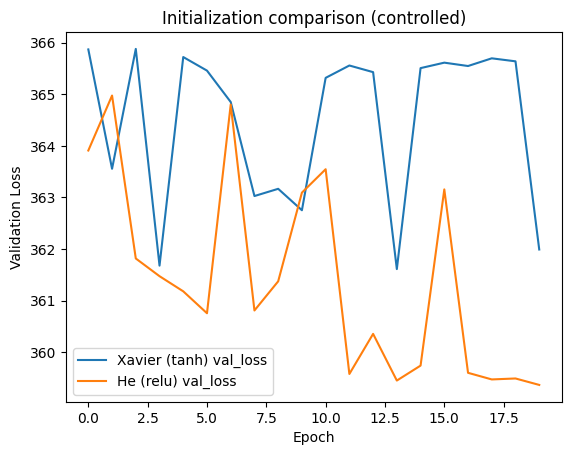

In [8]:
### Compile & Fit Different Model Types ###
xavier = keras.initializers.GlorotNormal(seed=SEED)
he     = keras.initializers.HeNormal(seed=SEED)

model_xavier = compile_model(
    build_basic_model(
        input_dim=input_dim,
        depth=10,
        width=10,
        activation="tanh",
        kernel_initializer=xavier
    ),
    keras.optimizers.Adam(learning_rate=1e-3)
)

model_he = compile_model(
    build_basic_model(
        input_dim=input_dim,
        depth=10,
        width=10,
        activation="relu",
        kernel_initializer=he
    ),
    keras.optimizers.Adam(learning_rate=1e-3)
)

# function call- do not change
hist_xavier = fit_model(model_xavier, epochs=20)
hist_he = fit_model(model_he, epochs=20)

plt.figure()
plt.plot(hist_xavier.history["val_loss"], label="Xavier (tanh) val_loss")
plt.plot(hist_he.history["val_loss"], label="He (relu) val_loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Initialization comparison (controlled)")
plt.show()

In [9]:
test_results = model_he.evaluate(
    X_test_p,
    y_test,
    verbose=0
)

print("Test Loss :", test_results[0])
print("Test MAE  :", test_results[1])
print("Test RMSE :", test_results[2])

Test Loss : 276.743896484375
Test MAE  : 7.252715587615967
Test RMSE : 16.635622024536133


##Starting GRU Model Testing

In [11]:
### Load Holiday Data ###

holidays = pd.read_csv(
    "readableData/holidays_events.csv",
    parse_dates=["date"]
)

print(holidays.head())

### Aggregate Company-Wide Daily Sales ###

daily_sales = (
    ds.groupby("date")["unit_sales"]
      .sum()
      .reset_index()
)

### Holiday Indicator ###

holiday_dates = holidays["date"].unique()

daily_sales["is_holiday"] = (
    daily_sales["date"]
    .isin(holiday_dates)
    .astype(int)
)

daily_sales.head()

        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4 2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  


,date,unit_sales,is_holiday
0,2013-01-01,2511.619,1
1,2013-01-02,496092.418,0
2,2013-01-03,361429.231,0
3,2013-01-04,354459.677,0
4,2013-01-05,477350.121,1


In [12]:
### Aggregate Company-Wide Daily Sales ###

daily_sales = (
    ds.groupby("date")["unit_sales"]
      .sum()
      .reset_index()
)

print(daily_sales.shape)
daily_sales.head()

(233, 2)


,date,unit_sales
0,2013-01-01,2511.619
1,2013-01-02,496092.418
2,2013-01-03,361429.231
3,2013-01-04,354459.677
4,2013-01-05,477350.121


In [13]:
### Day of Week Feature ###

daily_sales["day_of_week"] = (
    daily_sales["date"]
    .dt.dayofweek
)

daily_sales.head()

,date,unit_sales,day_of_week
0,2013-01-01,2511.619,1
1,2013-01-02,496092.418,2
2,2013-01-03,361429.231,3
3,2013-01-04,354459.677,4
4,2013-01-05,477350.121,5


In [14]:
from sklearn.preprocessing import MinMaxScaler

sales_scaler = MinMaxScaler()

sales_scaled = sales_scaler.fit_transform(
    daily_sales[["unit_sales"]]
)

In [16]:
holiday_dates = holidays["date"].unique()
daily_sales["is_holiday"] = (
    daily_sales["date"]
    .isin(holiday_dates)
    .astype(int)
)

holiday_feature = daily_sales[
    ["is_holiday"]
].values

combined_features = np.hstack(
    [sales_scaled, holiday_feature]
)

print(combined_features.shape)

(233, 2)


In [18]:
daily_sales = (
    ds
    .groupby("date")["unit_sales"]
    .sum()
    .reset_index()
)

print(daily_sales.shape)

daily_sales.head()

(233, 2)


,date,unit_sales
0,2013-01-01,2511.619
1,2013-01-02,496092.418
2,2013-01-03,361429.231
3,2013-01-04,354459.677
4,2013-01-05,477350.121


(232, 1)


In [19]:
WINDOW = 30

X_gru = []
y_gru = []

for i in range(WINDOW, len(combined_features)):

    X_gru.append(
        combined_features[i-WINDOW:i]
    )

    y_gru.append(
        sales_scaled[i]
    )

X_gru = np.array(X_gru)
y_gru = np.array(y_gru)

print(X_gru.shape)
print(y_gru.shape)

(203, 30, 2)
(203, 1)


In [21]:
print(daily_sales.shape)
print(X_gru.shape)
print(y_gru.shape)

(233, 2)
(203, 30, 2)
(203, 1)


In [22]:
split_idx = int(0.8 * len(X_gru))

X_train_gru = X_gru[:split_idx]
X_test_gru  = X_gru[split_idx:]

y_train_gru = y_gru[:split_idx]
y_test_gru  = y_gru[split_idx:]

print(X_train_gru.shape)
print(X_test_gru.shape)

(162, 30, 2)
(41, 30, 2)


In [23]:
### Final GRU Model ###

gru_model = keras.Sequential([

    keras.Input(shape=(30,2)),

    layers.GRU(
        64,
        return_sequences=True
    ),

    layers.Dropout(0.2),

    layers.GRU(
        32
    ),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(1)

])

gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,009 (89.88 KB)

 Trainable params: 23,009 (89.88 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
print(daily_sales.shape)
print(combined_features.shape)
print(X_gru.shape)
print(y_gru.shape)

(233, 2)
(233, 2)
(203, 30, 2)
(203, 1)


In [25]:
split_idx = int(0.8 * len(X_gru))

X_train_gru = X_gru[:split_idx]
X_test_gru = X_gru[split_idx:]

y_train_gru = y_gru[:split_idx]
y_test_gru = y_gru[split_idx:]

print(X_train_gru.shape)
print(X_test_gru.shape)

print(y_train_gru.shape)
print(y_test_gru.shape)

(162, 30, 2)
(41, 30, 2)
(162, 1)
(41, 1)


In [26]:
gru_model = keras.Sequential([

    keras.Input(shape=(30,2)),

    layers.GRU(
        64,
        return_sequences=True
    ),

    layers.Dropout(0.2),

    layers.GRU(
        32
    ),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(1)

])

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 30, 64)         │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,009 (89.88 KB)

 Trainable params: 23,009 (89.88 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
gru_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

In [28]:
## Added to help overfitting once val_loss remains
## relatively constant and prevent it from getting worse
## see Epochs 16-32 for refernce on stoppage when val_loss
## increases to 0.0040

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [29]:
history_gru = gru_model.fit(
    X_train_gru,
    y_train_gru,
    validation_data=(
        X_test_gru,
        y_test_gru
    ),
    epochs=200,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 0.2022 - mae: 0.3944 - rmse: 0.4496 - val_loss: 0.0182 - val_mae: 0.1008 - val_rmse: 0.1349
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0269 - mae: 0.1348 - rmse: 0.1641 - val_loss: 0.0224 - val_mae: 0.1009 - val_rmse: 0.1497
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0231 - mae: 0.1270 - rmse: 0.1521 - val_loss: 0.0176 - val_mae: 0.0936 - val_rmse: 0.1328
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0197 - mae: 0.1158 - rmse: 0.1402 - val_loss: 0.0175 - val_mae: 0.0935 - val_rmse: 0.1325
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0196 - mae: 0.1181 - rmse: 0.1399 - val_loss: 0.0179 - val_mae: 0.0909 - val_rmse: 0.1337
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0204 - mae: 0.1205 - rmse: 0.1429 - val_loss: 0.0179 - val_mae: 0.0903 - val_rmse: 0.1337
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0203 - mae: 0.1182 - rmse

In [30]:
gru_results = gru_model.evaluate(
    X_test_gru,
    y_test_gru,
    verbose=0
)

print("GRU Test Loss :", gru_results[0])
print("GRU Test MAE  :", gru_results[1])
print("GRU Test RMSE :", gru_results[2])

GRU Test Loss : 0.008587777614593506
GRU Test MAE  : 0.05062335729598999
GRU Test RMSE : 0.0926702618598938


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step


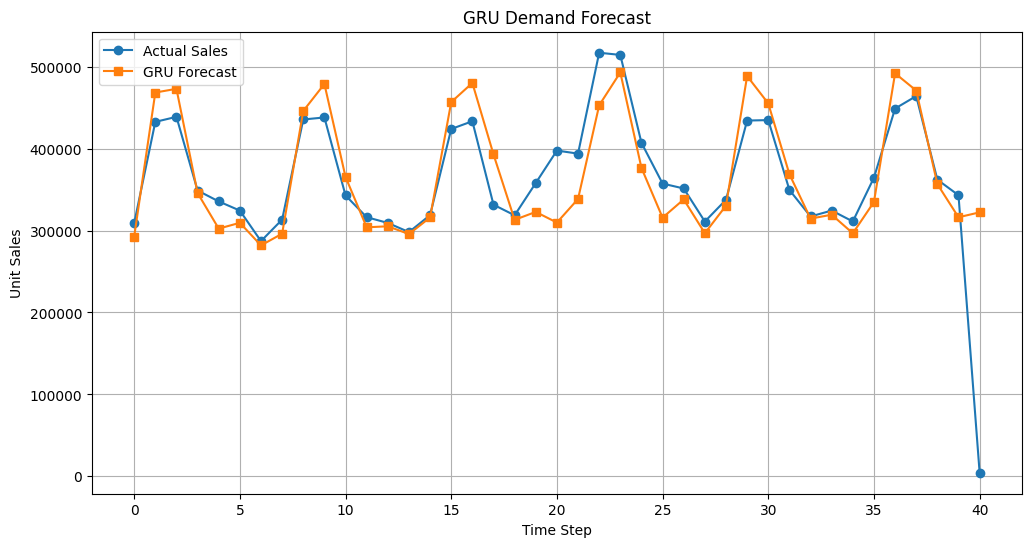

In [31]:
preds = gru_model.predict(X_test_gru)

preds_actual = sales_scaler.inverse_transform(preds)
actual_sales = sales_scaler.inverse_transform(y_test_gru)

plt.figure(figsize=(12,6))

plt.plot(actual_sales,
         marker='o',
         label="Actual Sales")

plt.plot(preds_actual,
         marker='s',
         label="GRU Forecast")

plt.title("GRU Demand Forecast")
plt.xlabel("Time Step")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True)

plt.show()

The GRU successfully learned overall demand trends but smoothed sudden spikes in demand. This suggests that additional explanatory variables such as promotions may further improve forecasting accuracy.

In [32]:
print("Min date:", ds["date"].min())
print("Max date:", ds["date"].max())
print("Unique dates:", ds["date"].nunique())
print("Rows:", len(ds))

Min date: 2013-01-01 00:00:00
Max date: 2013-08-21 00:00:00
Unique dates: 233
Rows: 10000000


##Order Recommendation

In [41]:
# ==========================================
# ORDER RECOMMENDATION MODULE
# RMSE-BASED SAFETY STOCK
# ==========================================

inventory_ratio = 0.75

inventory_available = actual_sales * inventory_ratio

# Safety stock based on forecast uncertainty
safety_stock = gru_results[2] * preds_actual

recommended_order = np.maximum(
    0,
    preds_actual + safety_stock - inventory_available
)

print("Average Safety Stock:",
      np.mean(safety_stock))

print("Average Recommended Order:",
      np.mean(recommended_order))

Average Safety Stock: 33974.582
Average Recommended Order: 128807.85815243902


Initially, the safety stock was hard-coded as 15% of the GRU demand forecast, resulting in an estimated food waste rate of approximately 13%. To create a more adaptive inventory strategy, the fixed safety stock percentage was replaced with a safety stock calculated using the GRU model's RMSE multiplied by the forecasted demand. This approach ties the inventory buffer directly to the model's prediction uncertainty.

Using the RMSE-based safety stock reduced the estimated food waste rate to approximately 8.5%, representing a reduction of about 35% compared to the original 15% safety stock approach. Additionally, because the safety stock is now based on the GRU model's performance, it will automatically adjust as future forecasting improvements and additional features (such as holidays, promotions, weather, or seasonal effects) are incorporated into the model.


##Food Waste Prediction

In [42]:
# ==========================================
# FOOD WASTE PREDICTION
# ==========================================

available_inventory = (
    inventory_available
    + recommended_order
)

predicted_waste = np.maximum(
    0,
    available_inventory - preds_actual
)

waste_percent = (
    predicted_waste /
    available_inventory
) * 100

print("Average Predicted Waste:",
      np.mean(predicted_waste))

print("Average Waste Percentage:",
      np.mean(waste_percent))

Average Predicted Waste: 33974.584603658535
Average Waste Percentage: 8.48108226679759


In [46]:
results_df = pd.DataFrame({

    'Actual_Sales': actual_sales.flatten(),

    'Forecast_Sales':
        preds_actual.flatten(),

    'Inventory':
        inventory_available.flatten(),

    'Recommended_Order':
        recommended_order.flatten(),

    'Predicted_Waste':
        predicted_waste.flatten(),

    'Waste_Percent':
        waste_percent.flatten()

})

print(results_df.head())

   Actual_Sales  Forecast_Sales     Inventory  Recommended_Order  \
0    308786.438    292534.68750  231589.82850        88054.10900   
1    432569.102    468377.87500  324426.82650       187355.73600   
2    438722.418    472908.59375  329041.81350       187691.34275   
3    348803.047    345727.31250  261602.28525       116163.65225   
4    335516.229    302295.78125  251637.17175        78672.45325   

   Predicted_Waste  Waste_Percent  
0      27109.25000       8.481077  
1      43404.68750       8.481080  
2      43824.56250       8.481082  
3      32038.62500       8.481078  
4      28013.84375       8.481086  


##Recommended Order Plot

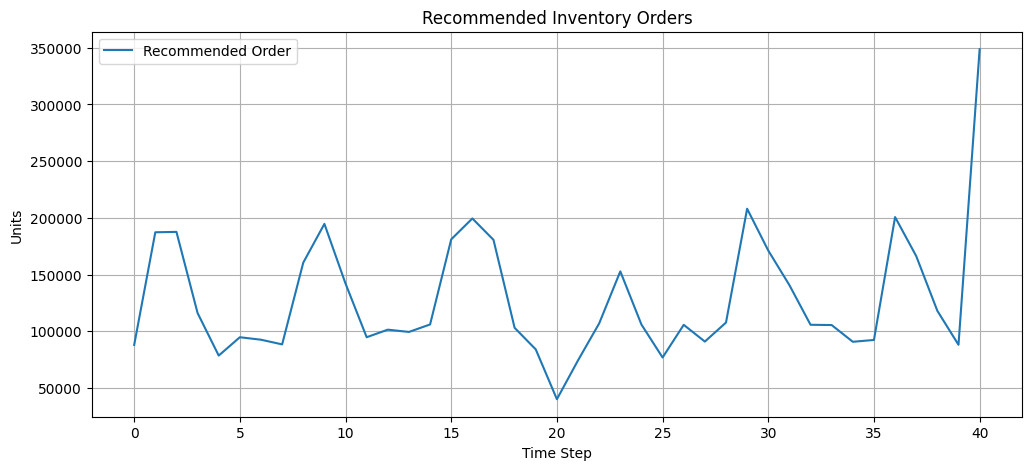

In [47]:
plt.figure(figsize=(12,5))

plt.plot(
    recommended_order,
    label='Recommended Order'
)

plt.title(
    'Recommended Inventory Orders'
)

plt.xlabel('Time Step')
plt.ylabel('Units')

plt.legend()
plt.grid(True)

plt.show()

##Waste Plot in Units

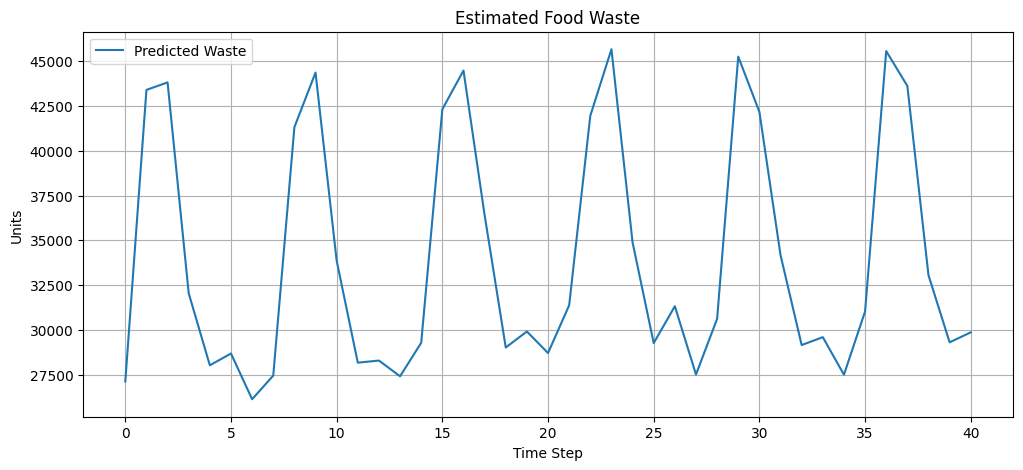

In [48]:
plt.figure(figsize=(12,5))

plt.plot(
    predicted_waste,
    label='Predicted Waste'
)

plt.title(
    'Estimated Food Waste'
)

plt.xlabel('Time Step')
plt.ylabel('Units')

plt.legend()
plt.grid(True)

plt.show()

##Waste Plot Percentage

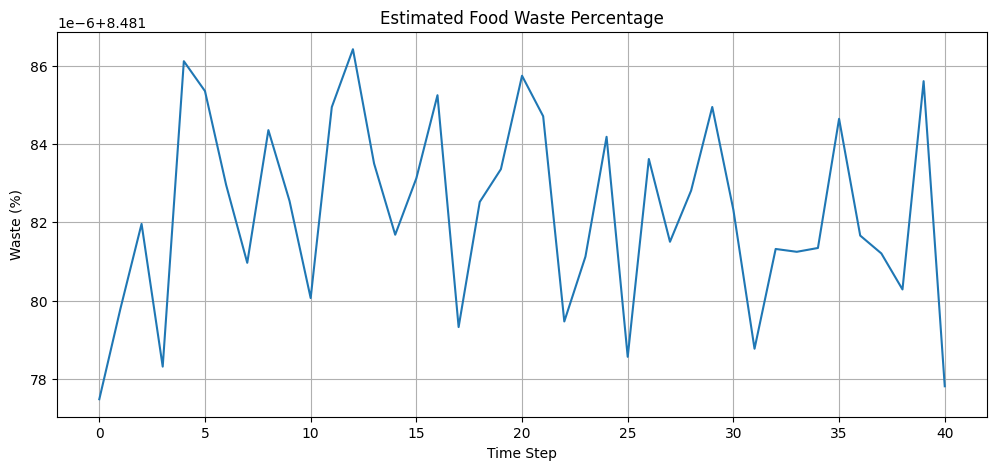

In [49]:
plt.figure(figsize=(12,5))

plt.plot(waste_percent)

plt.title("Estimated Food Waste Percentage")
plt.xlabel("Time Step")
plt.ylabel("Waste (%)")

plt.grid(True)
plt.show()

## Sales vs Waste Plot

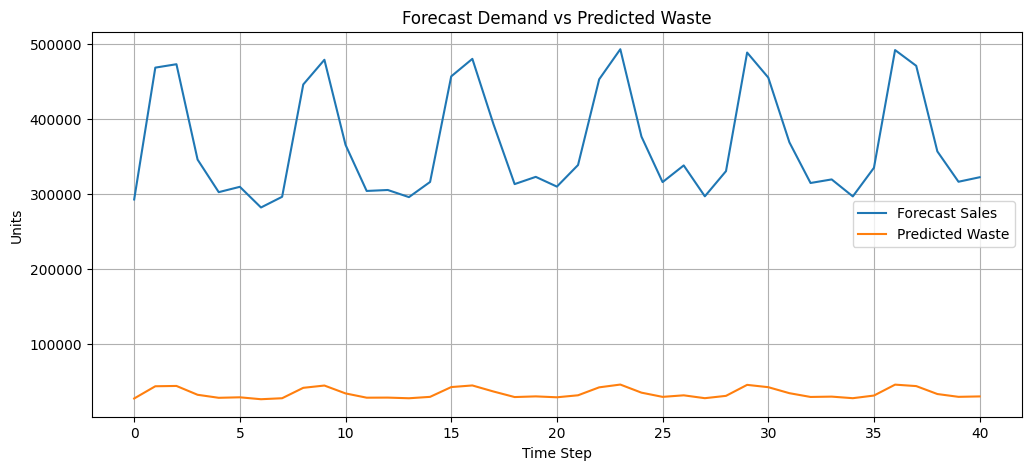

In [51]:
plt.figure(figsize=(12,5))

plt.plot(preds_actual,
         label='Forecast Sales')

plt.plot(predicted_waste,
         label='Predicted Waste')

plt.title('Forecast Demand vs Predicted Waste')

plt.xlabel('Time Step')
plt.ylabel('Units')

plt.legend()
plt.grid(True)

plt.show()

Small spikes in predicted food waste correspond to periods of high forecasted demand and actual sales. During these periods, the inventory recommendation system increases the safety stock based on the GRU model's RMSE to protect against forecast uncertainty. As a result, higher inventory levels are maintained during peak demand periods, leading to a temporary increase in predicted waste while reducing the risk of stockouts.